In [5]:
import cv2
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [6]:
### 영상 출력 함수
def fn_imshow(img, axis='on', **kwargs):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(**kwargs)
    if axis!='on': plt.axis('off')
    plt.imshow(img_rgb)
    plt.show()

In [7]:
from ultralytics import YOLO, checks

In [8]:
checks

<function ultralytics.utils.checks.check_yolo(verbose=True, device='')>

In [21]:
import requests

api_key = "uAcvdqqTSqA7VnQsp29r"
url = f"https://api.roboflow.com/?api_key={api_key}"

response = requests.get(url)
print(response.json())

{'welcome': 'Welcome to the Roboflow API.', 'instructions': 'You are successfully authenticated.', 'docs': 'https://docs.roboflow.com', 'workspace': 'kths-workspace'}


In [ ]:
import os
import glob
from roboflow import Roboflow


api_key = "uAcvdqqTSqA7VnQsp29r"
project_name = "broken_sidewalk_project_th"
version = 1  


rf = Roboflow(api_key=api_key)
project = rf.workspace().project(project_name)
model = project.version(version).model


image_folder = r"C:/Users/USER/OneDrive/바탕 화면/2-2 프로젝트/이미지분석 프로젝트/roboflow"


image_files = glob.glob(os.path.join(image_folder, "*.jpg"))


for image_path in image_files:
    print(f"처리 중: {image_path}")
    try:
        result = model.predict(image_path, confidence=40, overlap=30).json()  
        print(f"결과: {result}")  

        
        
        result_file = image_path.replace(".jpg", "_result.txt")
        with open(result_file, "w") as f:
            f.write(str(result))  
        print(f"결과 저장: {result_file}")
    
    except Exception as e:
        print(f"오류 발생: {e}")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
train: "C:/Users/USER/OneDrive/바탕 화면/2-2 프로젝트/이미지분석 프로젝트/roboflow/train"  
val: "C:/Users/USER/OneDrive/바탕 화면/2-2 프로젝트/이미지분석 프로젝트/roboflow/valid"  
test:"C:/Users/USER/OneDrive/바탕 화면/2-2 프로젝트/이미지분석 프로젝트/roboflow/test"

nc: 5  
names: ['pothole','crack','asphalt','gap','null']  


In [ ]:
import os
from ultralytics import YOLO



model = YOLO("yolo11n.yaml")


data_yaml = "C:/Users/USER/OneDrive/바탕 화면/2-2 프로젝트/이미지분석 프로젝트/roboflow/data.yaml"


model.train(
      data=data_yaml,      # 데이터 설정 파일
    epochs=100,          # 학습 반복 횟수
    batch=8,             # 배치 크기
    imgsz=640,           # 이미지 크기
    workers=2,           # DataLoader 워커 수
    lr0=0.02,            # 초기 학습률
    warmup_epochs=3,     # Warm-Up 적용
    lrf=0.01,            # 최종 학습률 비율
    device="cpu"         # CPU 또는 GPU 설정 ("cpu", "0", "0,1" 등)
)
print("모델 학습 완료")

New https://pypi.org/project/ultralytics/8.3.48 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.38  Python-3.12.4 torch-2.4.1+cpu CPU (12th Gen Intel Core(TM) i7-1260P)
engine\trainer: task=detect, mode=train, model=yolo11n.yaml, data=C:/Users/USER/OneDrive/ /2-2 / /roboflow/data.yaml, epochs=100, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=cpu, workers=2, project=None, name=train38, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, emb

train: Scanning C:\Users\USER\OneDrive\바탕 화면\2-2 프로젝트\이미지분석 프로젝트\roboflow\train\labels.cache... 700 images, 1 backgrounds, 0 corrupt: 100%|██████████| 700/700 [00:00<?, ?it/s]
val: Scanning C:\Users\USER\OneDrive\바탕 화면\2-2 프로젝트\이미지분석 프로젝트\roboflow\valid\labels.cache... 106 images, 1 backgrounds, 0 corrupt: 100%|██████████| 106/106 [00:00<?, ?it/s]

Plotting labels to runs\detect\train38\labels.jpg... 


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.02' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.00125, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to runs\detect\train38
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      1/100         0G      3.821      4.793      4.306         20        640:   5%|▍         | 4/88 [00:10<03:31,  2.51s/it]


KeyboardInterrupt: 

In [28]:
%matplotlib inline


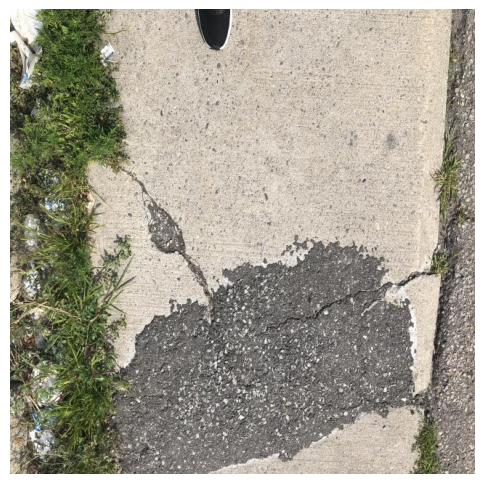

In [144]:
img = cv2.imread(r"C:/DATA/img_test.jpg")


fn_imshow(img, axis='off', figsize=(6, 8))


In [145]:
results = model.predict(r"C:/DATA/img_test.jpg")  


image = cv2.imread(r"C:/DATA/img_test.jpg")


image 1/1 C:\DATA\img_test.jpg: 640x640 (no detections), 129.7ms
Speed: 3.5ms preprocess, 129.7ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)


In [146]:
pt_path = r"C:/Users/USER/OneDrive/바탕 화면/2-2 프로젝트/이미지분석 프로젝트/runs/detect/train37/weights/best.pt"
model_best = YOLO(pt_path)

In [147]:
src =r"C:/DATA/img_test.jpg"
source = cv2.imread(src)

results = model_best(source)


0: 640x640 2 asphalts, 96.9ms
Speed: 4.0ms preprocess, 96.9ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


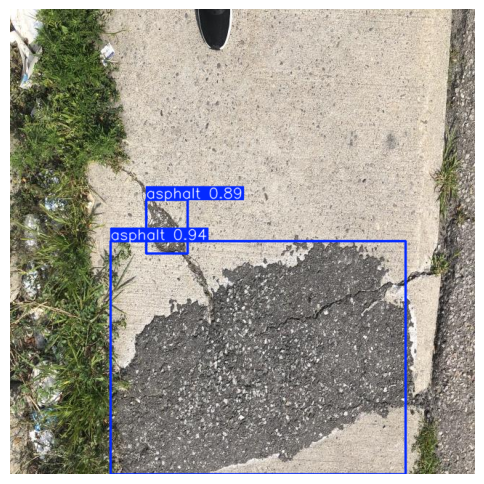

In [148]:
res_plotted = results[0].plot()
fn_imshow(res_plotted, axis='off', figsize=(6, 8))


In [152]:
### Boxes
boxes = results[0].boxes
### Classe names
face_mask_classnames = {
    0: 'crack',
    1: 'No crack'
}

### DataFrame
boxes_arr = boxes.data.cpu().numpy()
col_names = ['xMin', 'yMin', 'xMax', 'yMax', 'conf', 'class']
boxes_df = pd.DataFrame(boxes_arr, columns=col_names)

### Add class names
boxes_df['class'] = boxes_df['class'].astype('int')
boxes_df['class_nm'] = [face_mask_classnames[i] for i in boxes_df['class']]
boxes_df

,xMin,yMin,xMax,yMax,conf,class,class_nm
0,138.549072,319.459412,544.393433,640.000000,0.937598,0,crack
1,187.892242,262.355835,244.636871,336.928223,0.889639,0,crack


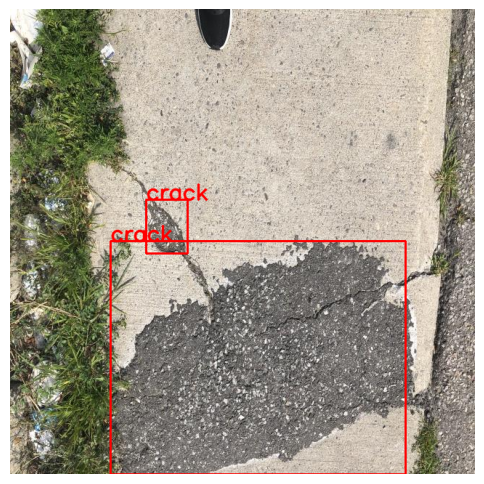

In [153]:
img_out = source.copy()
for i in range(boxes_df.shape[0]):
    ind_box = boxes_df.iloc[i][0:4].astype('int')
    ind_class = boxes_df.iloc[i][5].astype('int')
    ind_col = (0,0,255) if ind_class==0 else (255,0,0)
    cv2.rectangle(img_out, ind_box[:2], ind_box[2:], ind_col, 2)
    ind_class_nm = boxes_df.iloc[i][6]
    cv2.putText(img_out,ind_class_nm,ind_box[:2], 0, 1,ind_col,2,cv2.LINE_AA)

fn_imshow(img_out, figsize=(6,8), axis='')

In [ ]:
src="C:/DATA/videoplayback.mp4"
results_mp4=model_best(src,save=True,verbose=False)


WARNING  inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to runs\detect\predict
